In [61]:
import numpy as np                                  # numerical arrays
import pandas as pd                                 # excel / dataframe loading
import torch                                        # main deep learning framework
import torch.nn as nn                              # neural network building blocks
import torch.nn.functional as F                    # activation functions, etc.
from torch.utils.data import Dataset, DataLoader   # batching utilities
from torch_geometric.nn import MessagePassing       # pyg base class for graph convolutions
from sklearn.preprocessing import StandardScaler   # z-score normalisation
import matplotlib.pyplot as plt                    # plots

torch.manual_seed(42)   # fix random seed for reproducibility
np.random.seed(42)      # fix numpy seed as well
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # use gpu if available
print('Device:', device)

Device: cuda


In [62]:
nodes_df = pd.read_excel('./Gas Network Data.xlsx', sheet_name='Nodes')       # node metadata (shares, etc.)
pipes_df = pd.read_excel('./Gas Network Data.xlsx', sheet_name='Pipelines')    # pipeline topology

months = [str(m).zfill(2) + '-2024' for m in range(1, 13)]   # list of sheet names for each month

res_total = pd.concat(                                                          # residential consumption [T]
    [pd.read_excel('./input/Gas Cons Distrib.xlsx', sheet_name=m)['Physical Flow (MNm3)'] for m in months],
    ignore_index=True
).values.astype(np.float32)

ind_total = pd.concat(                                                          # industrial consumption [T]
    [pd.read_excel('./input/Gas Cons Ind.xlsx', sheet_name=m)['Physical Flow (MNm3)'] for m in months],
    ignore_index=True
).values.astype(np.float32)

exp_total = pd.concat(                                                          # export consumption [T]
    [pd.read_excel('./input/Gas Cons Export.xlsx', sheet_name=m)['Physical Flow (MNm3)'] for m in months],
    ignore_index=True
).values.astype(np.float32)

q_full = pd.concat(                                                             # pipeline flow rates [T, 33]
    [pd.read_excel('./output/Decision_variablesRU.xlsx', sheet_name=f'q-{m}').iloc[:, 1:] for m in months],
    ignore_index=True
).values.astype(np.float32)

g_full = pd.concat(                                                             # well injections [T, 4] — this is the target
    [pd.read_excel('./output/Decision_variablesRU.xlsx', sheet_name=f'g-{m}')[[0, 1, 2, 3]] for m in months],
    ignore_index=True
).values.astype(np.float32)

print('q_full:', q_full.shape)
print('g_full:', g_full.shape)

q_full: (8784, 33)
g_full: (8784, 4)


In [63]:
N        = 28
T        = 8784
W_IN     = 72
W_OUT    = 24
BLOCK    = W_IN + W_OUT
WELL_IDX = [0, 4, 16, 17]

nodes_df  = nodes_df.sort_values('Gas Node').reset_index(drop=True)

res_share = nodes_df['Res_Load_share_%'].values.astype(np.float32)
ind_share = nodes_df['Ind_Load_share_%'].values.astype(np.float32)
exp_share = nodes_df['Exp_Load_share_%'].values.astype(np.float32)

X_cons = np.stack([
    np.outer(res_total, res_share),
    np.outer(ind_total, ind_share),
    np.outer(exp_total, exp_share),
], axis=-1).astype(np.float32)

X_global = np.stack([
    np.tile(res_total[:, None], (1, N)),
    np.tile(ind_total[:, None], (1, N)),
    np.tile(exp_total[:, None], (1, N)),
], axis=-1).astype(np.float32)

g_node = np.zeros((T, N), dtype=np.float32)
g_node[:, WELL_IDX] = g_full

X_full = np.concatenate([X_cons, X_global, g_node[:, :, None]], axis=-1)   # [T, N, 7]

cols_to_norm = list(range(0, 6)) + [6]
x_scaler = StandardScaler().fit(X_full[:, :, cols_to_norm].reshape(-1, len(cols_to_norm)))
X_full[:, :, cols_to_norm] = x_scaler.transform(
    X_full[:, :, cols_to_norm].reshape(-1, len(cols_to_norm))
).reshape(T, N, len(cols_to_norm))

Y_all    = g_full.astype(np.float32)
y_scaler = StandardScaler().fit(Y_all)
Y_norm   = y_scaler.transform(Y_all).astype(np.float32)

print(f'X_full : {X_full.shape}')

X_full : (8784, 28, 7)


In [64]:
# =========================================================
# 3. EDGE INDEX + EDGE FEATURES (UNIQUEMENT STATIQUES)
# =========================================================
import numpy as np
from sklearn.preprocessing import StandardScaler

pipes_df = pipes_df[['Pipeline', 'From node', 'To node',
                     'Compressor factor', 'Estimated lenght [km]']].copy()
pipes_df['Estimated lenght [km]'] = pipes_df['Estimated lenght [km]'].fillna(0.0)
pipes_df['Compressor factor']     = pipes_df['Compressor factor'].fillna(1.0)

edge_pairs   = []
pipe_to_edge = []

for i, row in pipes_df.iterrows():
    u = int(row['From node']) - 1
    v = int(row['To node'])   - 1

    idx_fwd = len(edge_pairs)
    edge_pairs.append((u, v))

    idx_bwd = len(edge_pairs)
    edge_pairs.append((v, u))

    pipe_to_edge.append((idx_fwd, idx_bwd))

edge_index = np.array(edge_pairs, dtype=np.int64).T   # [2, E]
E = edge_index.shape[1]

# ---------------------------------------------------------
# Features statiques d'arête
# -> 2 features : compressor factor, estimated length
# Dupliquées pour l'arête aller et retour
# ---------------------------------------------------------
static_edge = np.array([
    [pipes_df.iloc[p]['Compressor factor'],
     pipes_df.iloc[p]['Estimated lenght [km]']]
    for p, _ in enumerate(pipe_to_edge)
    for _ in range(2)
], dtype=np.float32)   # [E, 2]

static_scaler    = StandardScaler().fit(static_edge)
static_edge_norm = static_scaler.transform(static_edge).astype(np.float32)   # [E, 2]

# ---------------------------------------------------------
# On répète les mêmes features à chaque heure
# ---------------------------------------------------------
EA_full = np.tile(static_edge_norm[None, :, :], (T, 1, 1)).astype(np.float32)   # [T, E, 2]

ei = torch.tensor(edge_index, dtype=torch.long, device=device)

print(f'edge_index        : {edge_index.shape}')
print(f'static_edge_norm  : {static_edge_norm.shape}')
print(f'EA_full           : {EA_full.shape}')

edge_index        : (2, 66)
static_edge_norm  : (66, 2)
EA_full           : (8784, 66, 2)


In [65]:
starts = np.arange(0, T - BLOCK + 1, 6)   # start index of each window (step=6h)

X_win  = np.stack([X_full[s : s + W_IN]         for s in starts])   # [S, 72, N, 11]
EA_win = np.stack([EA_full[s : s + W_IN]         for s in starts])   # [S, 72, E, 1]
#Y_win  = np.stack([Y_norm[s + W_IN : s + BLOCK]  for s in starts])   # [S, 24, 4]

Y_win_abs = np.stack([Y_norm[s + W_IN : s + BLOCK] for s in starts])   # [S, 24, 4]
Y_last    = np.stack([Y_norm[s + W_IN - 1]          for s in starts])   # [S, 4]

# target = delta par rapport à la dernière heure observée
Y_win = Y_win_abs - Y_last[:, None, :]


S       = len(starts)
s_train = int(0.70 * S)   # 70% training
s_val   = int(0.85 * S)   # 15% validation

X_train,  Y_train  = X_win[:s_train],       Y_win[:s_train]
X_val,    Y_val    = X_win[s_train:s_val],  Y_win[s_train:s_val]
X_test,   Y_test   = X_win[s_val:],         Y_win[s_val:]
EA_train = EA_win[:s_train]
EA_val   = EA_win[s_train:s_val]
EA_test  = EA_win[s_val:]

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Train: 1014  Val: 217  Test: 218


In [66]:
class GasDataset(Dataset):
    def __init__(self, X, EA, Y):
        self.X  = torch.tensor(X,  dtype=torch.float32)   # node features [S, 72, N, 11]
        self.EA = torch.tensor(EA, dtype=torch.float32)   # edge features [S, 72, E, 1]
        self.Y  = torch.tensor(Y,  dtype=torch.float32)   # targets        [S, 24, 4]

    def __len__(self):
        return len(self.X)   # number of windows

    def __getitem__(self, idx):
        return self.X[idx], self.EA[idx], self.Y[idx]   # one sample

BATCH = 24

train_loader = DataLoader(GasDataset(X_train, EA_train, Y_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(GasDataset(X_val,   EA_val,   Y_val),   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(GasDataset(X_test,  EA_test,  Y_test),  batch_size=BATCH, shuffle=False)

print(f'Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}')

Batches — train:43  val:10  test:10


In [67]:
# =========================================================
# 6. MODEL
# =========================================================
import torch
import torch.nn as nn
from torch_geometric.utils import softmax

IN_DIM   = X_full.shape[-1]     # ex: 7 si tu gardes les noeuds actuels
EDGE_DIM = EA_full.shape[-1]    # ici = 2
H        = 96
MP_STEPS = 2
OUT_H    = W_OUT
N_WELLS  = 4
DROPOUT  = 0.2

print("IN_DIM  =", IN_DIM)
print("EDGE_DIM=", EDGE_DIM)


def batch_edge_index(edge_index, batch_size, num_nodes, device):
    # edge_index: [2, E]
    E = edge_index.shape[1]
    offsets = torch.arange(batch_size, device=device).repeat_interleave(E) * num_nodes
    ei = edge_index.repeat(1, batch_size) + offsets
    return ei


class EdgeWeightedConv(nn.Module):
    def __init__(self, h_dim, edge_dim):
        super().__init__()
        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * h_dim + edge_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim)
        )
        self.upd = nn.Sequential(
            nn.Linear(2 * h_dim, h_dim),
            nn.ReLU()
        )

    def forward(self, x, edge_index, edge_attr):
        # x         : [B*N, h_dim]
        # edge_index: [2, B*E]
        # edge_attr : [B*E, edge_dim]

        src, dst = edge_index
        msg_in = torch.cat([x[src], x[dst], edge_attr], dim=-1)   # [B*E, 2h+edge_dim]
        m = self.msg_mlp(msg_in)                                  # [B*E, h_dim]

        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, m)

        out = self.upd(torch.cat([x, agg], dim=-1))
        return out


class SimpleGNN(nn.Module):
    def __init__(self, in_dim, edge_dim, h_dim=96, mp_steps=2, out_h=24, n_wells=4, dropout=0.2):
        super().__init__()

        self.edge_dim = edge_dim
        self.h_dim    = h_dim
        self.out_h    = out_h
        self.n_wells  = n_wells

        self.encoder = nn.Sequential(
            nn.Linear(in_dim, h_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h_dim, h_dim),
            nn.ReLU()
        )

        self.mp_layers = nn.ModuleList([
            EdgeWeightedConv(h_dim, edge_dim) for _ in range(mp_steps)
        ])

        self.time_attn = nn.Sequential(
            nn.Linear(h_dim, h_dim),
            nn.Tanh(),
            nn.Linear(h_dim, 1)
        )

        # embeddings spécifiques aux noeuds
        self.node_embed = nn.Parameter(torch.randn(28, h_dim) * 0.01)

        self.decoder = nn.Sequential(
            nn.Linear(h_dim * n_wells, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, out_h * n_wells)
        )

    def forward(self, x, ea_seq, edge_index):
        # x      : [B, W, N, F]
        # ea_seq : [B, W, E, edge_dim]
        B, W, N, F = x.shape
        E = ea_seq.shape[2]

        ei_batch = batch_edge_index(edge_index, B, N, x.device)

        h_seq = []
        for t in range(W):
            ht   = self.encoder(x[:, t].reshape(B * N, F))                # [B*N, h_dim]
            ea_t = ea_seq[:, t].reshape(B * E, self.edge_dim)            # [B*E, edge_dim]

            for mp in self.mp_layers:
                ht = mp(ht, ei_batch, ea_t)

            ht = ht.view(B, N, self.h_dim) + self.node_embed[None, :, :]
            h_seq.append(ht)

        h_seq = torch.stack(h_seq, dim=1)   # [B, W, N, h_dim]

        scores = torch.softmax(self.time_attn(h_seq), dim=1)   # [B, W, N, 1]
        h = (h_seq * scores).sum(dim=1)                        # [B, N, h_dim]

        well_h = h[:, WELL_IDX, :].reshape(B, -1)              # [B, 4*h_dim]
        out = self.decoder(well_h).view(B, self.out_h, self.n_wells)
        return out


model = SimpleGNN(
    in_dim=IN_DIM,
    edge_dim=EDGE_DIM,
    h_dim=H,
    mp_steps=MP_STEPS,
    out_h=OUT_H,
    n_wells=N_WELLS,
    dropout=DROPOUT
).to(device)

print(model)

IN_DIM  = 7
EDGE_DIM= 2
SimpleGNN(
  (encoder): Sequential(
    (0): Linear(in_features=7, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=96, out_features=96, bias=True)
    (4): ReLU()
  )
  (mp_layers): ModuleList(
    (0-1): 2 x EdgeWeightedConv(
      (msg_mlp): Sequential(
        (0): Linear(in_features=194, out_features=96, bias=True)
        (1): ReLU()
        (2): Linear(in_features=96, out_features=96, bias=True)
      )
      (upd): Sequential(
        (0): Linear(in_features=192, out_features=96, bias=True)
        (1): ReLU()
      )
    )
  )
  (time_attn): Sequential(
    (0): Linear(in_features=96, out_features=96, bias=True)
    (1): Tanh()
    (2): Linear(in_features=96, out_features=1, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=96, bias=True)
  )

In [68]:
# =========================================================
# 7. WINDOWS + DATASETS + LOADERS
# =========================================================
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

starts = np.arange(0, T - BLOCK + 1, 6)

X_win  = np.stack([X_full[s : s + W_IN]          for s in starts])   # [S, 72, N, IN_DIM]
EA_win = np.stack([EA_full[s : s + W_IN]         for s in starts])   # [S, 72, E, EDGE_DIM]
Y_win  = np.stack([Y_norm[s + W_IN : s + BLOCK]  for s in starts])   # [S, 24, 4]

print("X_win :", X_win.shape)
print("EA_win:", EA_win.shape)
print("Y_win :", Y_win.shape)

S = len(starts)
s_train = int(0.70 * S)
s_val   = int(0.85 * S)

X_train, EA_train, Y_train = X_win[:s_train],           EA_win[:s_train],           Y_win[:s_train]
X_val,   EA_val,   Y_val   = X_win[s_train:s_val],      EA_win[s_train:s_val],      Y_win[s_train:s_val]
X_test,  EA_test,  Y_test  = X_win[s_val:],             EA_win[s_val:],             Y_win[s_val:]

print("\nTrain:", X_train.shape, EA_train.shape, Y_train.shape)
print("Val  :", X_val.shape, EA_val.shape, Y_val.shape)
print("Test :", X_test.shape, EA_test.shape, Y_test.shape)


class SeqDataset(Dataset):
    def __init__(self, X, EA, Y):
        self.X  = torch.tensor(X, dtype=torch.float32)
        self.EA = torch.tensor(EA, dtype=torch.float32)
        self.Y  = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.EA[idx], self.Y[idx]


train_ds = SeqDataset(X_train, EA_train, Y_train)
val_ds   = SeqDataset(X_val,   EA_val,   Y_val)
test_ds  = SeqDataset(X_test,  EA_test,  Y_test)

BATCH = 32

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

xb, eab, yb = next(iter(train_loader))
print("\nMini-batch check:")
print("xb  :", xb.shape)   # [B, 72, N, IN_DIM]
print("eab :", eab.shape)  # [B, 72, E, 2]
print("yb  :", yb.shape)   # [B, 24, 4]

X_win : (1449, 72, 28, 7)
EA_win: (1449, 72, 66, 2)
Y_win : (1449, 24, 4)

Train: (1014, 72, 28, 7) (1014, 72, 66, 2) (1014, 24, 4)
Val  : (217, 72, 28, 7) (217, 72, 66, 2) (217, 24, 4)
Test : (218, 72, 28, 7) (218, 72, 66, 2) (218, 24, 4)

Mini-batch check:
xb  : torch.Size([32, 72, 28, 7])
eab : torch.Size([32, 72, 66, 2])
yb  : torch.Size([32, 24, 4])


In [69]:
# =========================================================
# 8. TRAIN
# =========================================================
EPOCHS   = 300
LR       = 5e-4
PATIENCE = 20

import torch
import torch.nn as nn

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

best_val = float('inf')
patience_cnt = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # Train
    # -------------------------
    model.train()
    total = 0.0

    for xb, eab, yb in train_loader:
        xb, eab, yb = xb.to(device), eab.to(device), yb.to(device)

        optimizer.zero_grad()

        pred = model(xb, eab, ei)
        loss = criterion(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * len(xb)

    train_loss = total / len(train_loader.dataset)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    total = 0.0

    with torch.no_grad():
        for xb, eab, yb in val_loader:
            xb, eab, yb = xb.to(device), eab.to(device), yb.to(device)

            pred = model(xb, eab, ei)
            loss = criterion(pred, yb)

            total += loss.item() * len(xb)

    val_loss = total / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f'Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}  lr={optimizer.param_groups[0]["lr"]:.2e}')

    if val_loss < best_val:
        best_val = val_loss
        patience_cnt = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stop at epoch {epoch}')
            break

Epoch   1 | train=1.0171  val=0.7513  lr=5.00e-04
Epoch   2 | train=0.8348  val=0.7396  lr=5.00e-04
Epoch   3 | train=0.8067  val=0.7223  lr=5.00e-04
Epoch   4 | train=0.7977  val=0.7381  lr=5.00e-04
Epoch   5 | train=0.7859  val=0.7277  lr=5.00e-04
Epoch   6 | train=0.7727  val=0.7194  lr=5.00e-04
Epoch   7 | train=0.7558  val=0.7115  lr=5.00e-04
Epoch   8 | train=0.7508  val=0.6973  lr=5.00e-04
Epoch   9 | train=0.7503  val=0.6984  lr=5.00e-04
Epoch  10 | train=0.7434  val=0.7033  lr=5.00e-04
Epoch  11 | train=0.7432  val=0.7024  lr=5.00e-04
Epoch  12 | train=0.7417  val=0.6958  lr=5.00e-04
Epoch  13 | train=0.7434  val=0.7104  lr=5.00e-04
Epoch  14 | train=0.7394  val=0.6953  lr=5.00e-04
Epoch  15 | train=0.7377  val=0.6940  lr=5.00e-04
Epoch  16 | train=0.7394  val=0.7375  lr=5.00e-04
Epoch  17 | train=0.7386  val=0.6964  lr=5.00e-04
Epoch  18 | train=0.7380  val=0.7161  lr=5.00e-04
Epoch  19 | train=0.7370  val=0.6962  lr=5.00e-04
Epoch  20 | train=0.7351  val=0.6997  lr=5.00e-04


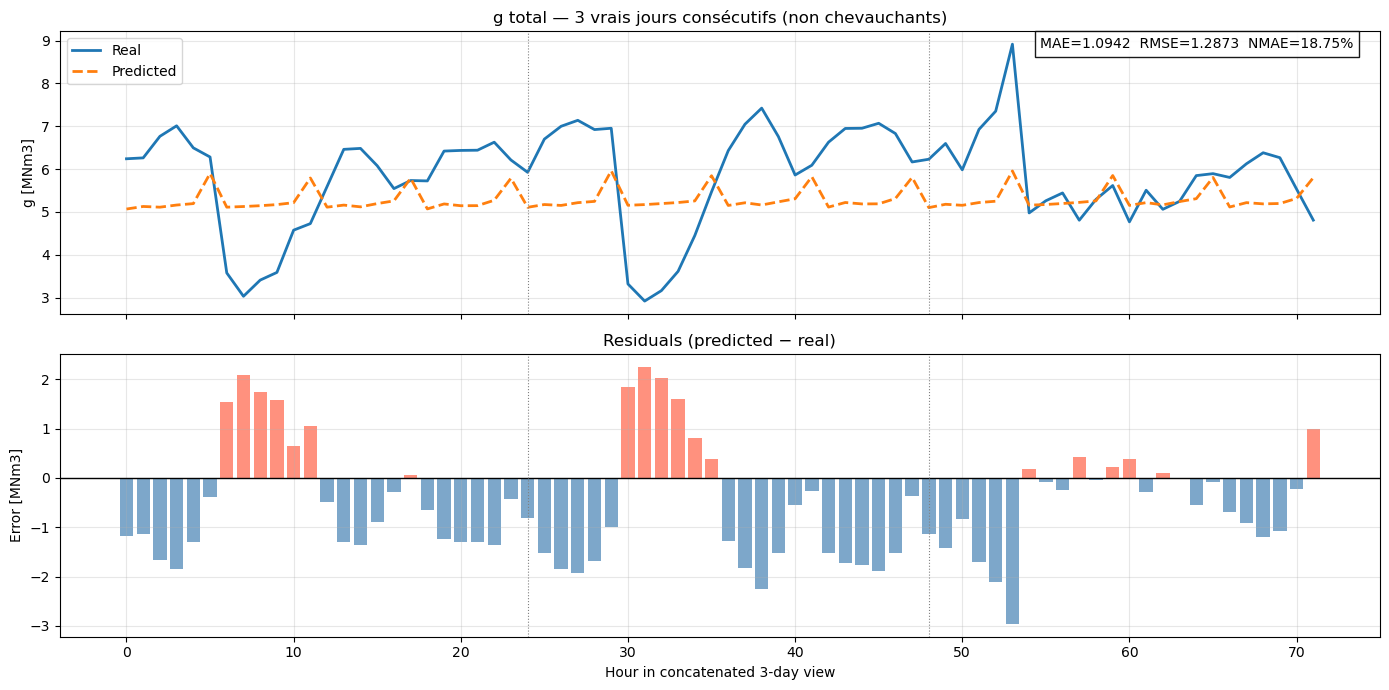

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# 3 jours réellement non chevauchants
# ---------------------------------
base_k = 0
selected = [base_k, base_k + 4, base_k + 8]

total_true_cont = []
total_pred_cont = []
x_cont = []

offset = 0
for kk in selected:
    s = starts_test[kk]
    idx = np.arange(s + W_IN, s + BLOCK)   # indices réels du target

    total_true_cont.append(g_full[idx].sum(axis=1))   # vrai total brut
    total_pred_cont.append(preds_real[kk].sum(axis=1))  # prédiction du modèle
    x_cont.append(np.arange(offset, offset + 24))
    offset += 24

total_true_cont = np.concatenate(total_true_cont)
total_pred_cont = np.concatenate(total_pred_cont)
x_cont = np.concatenate(x_cont)

mae = np.mean(np.abs(total_pred_cont - total_true_cont))
rmse = np.sqrt(np.mean((total_pred_cont - total_true_cont) ** 2))
nmae = 100 * mae / np.mean(np.abs(total_true_cont))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ---- haut : séries
axes[0].plot(x_cont, total_true_cont, label='Real', lw=2)
axes[0].plot(x_cont, total_pred_cont, label='Predicted', lw=2, ls='--')

for d in range(1, 3):
    axes[0].axvline(d * 24, color='grey', ls=':', lw=0.8)

axes[0].set_title("g total — 3 vrais jours consécutifs (non chevauchants)")
axes[0].set_ylabel("g [MNm3]")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[0].text(
    0.98, 0.98,
    f"MAE={mae:.4f}  RMSE={rmse:.4f}  NMAE={nmae:.2f}%",
    transform=axes[0].transAxes,
    ha='right', va='top',
    bbox=dict(facecolor='white', alpha=0.9)
)

# ---- bas : résidus
res = total_pred_cont - total_true_cont
colors = ['tomato' if r > 0 else 'steelblue' for r in res]

axes[1].bar(x_cont, res, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', lw=1)

for d in range(1, 3):
    axes[1].axvline(d * 24, color='grey', ls=':', lw=0.8)

axes[1].set_title("Residuals (predicted − real)")
axes[1].set_xlabel("Hour in concatenated 3-day view")
axes[1].set_ylabel("Error [MNm3]")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()